# 01 - Setup and Head Discovery

This notebook covers environment setup, model loading, embedding cache construction, and head-alignment discovery/visual diagnostics.


In [ ]:
# === CONFIG ===
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Model & checkpoint
RUN_NAME = "objrel_T5_DiT_mini_pilot"
CHECKPOINT_EPOCH = 4000
CHECKPOINT_STEP = 160000

# Dataset
COLORS = ["red", "blue"]
SHAPES = ["square", "triangle", "circle"]
SPATIAL_RELATIONS = ["above", "below", "left_of", "right_of",
                     "upper_left", "upper_right", "lower_left", "lower_right"]

# Variance partition
N_PERM = 100
VP_FEATURES = ["spatial_relationship", "color1", "shape1", "color2", "shape2",
               "color1shape1", "color2shape2"]

# Head screening
POS_EMBED_BASE_SIZE = 8  # 16//2 for mini model
ALIGNMENT_COSINE_THRESHOLD = 0.7

# Evolution checkpoints
EVOLUTION_EPOCHS = [100, 250, 500, 600, 700, 750, 800, 900, 1000, 2000, 4000]
EMERGENCE_EPOCHS = [500, 600, 700, 750, 800, 900, 1000]

# Permutation null for significance
N_PERM_NULL = 200  # shuffled-label null distribution for alignment scores

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Fix SSL certificates on macOS
import os, ssl, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import os
from os.path import join
import torch
import torch as th
import torch.nn.functional as F
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
from tqdm.auto import trange
from contextlib import redirect_stdout
import sys
sys.path.append("/Users/julianali/Desktop/DiffusionInterp/PixArt-alpha")
from diffusion.data.builder import build_dataset, build_dataloader, set_data_root
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/Users/julianali/Desktop/DiffusionInterp")
from utils.cv2_eval_utils import evaluate_pipeline_on_prompts, print_evaluation_summary
from utils.relation_shape_dataset_lib import ShapesDataset
from utils.variance_partition_with_effects import variance_partition_with_effects
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom, PixArtAlphaPipeline_custom_CLIP
from utils.pixart_utils import state_dict_convert, load_pixart_ema_into_transformer
from utils.pixart_utils import construct_diffuser_pipeline_from_config, PixArt_model_configs
from utils.text_encoder_control_lib import RandomEmbeddingEncoder_wPosEmb
from utils.image_utils import pil_images_to_grid
from utils.attention_map_store_utils import replace_attn_processor, AttnProcessor2_0_Store, PixArtAttentionVisualizer_Store
from utils.cv2_eval_utils import find_classify_object_masks
from diffusers import AutoencoderKL, Transformer2DModel, PixArtAlphaPipeline, DPMSolverMultistepScheduler
from transformers import T5Tokenizer, T5EncoderModel

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    compute_dtype = torch.float32
else:
    device = "cpu"
    compute_dtype = torch.float32
print(f"Using device: {device}, compute dtype: {compute_dtype}")

def saveallforms(figdir, fname, figh=None, fmts=("png", "pdf")):
    """Local replacement for circuit_toolkit.plot_utils.saveallforms"""
    os.makedirs(figdir, exist_ok=True)
    fig = figh if figh is not None else plt.gcf()
    for fmt in fmts:
        fig.savefig(os.path.join(figdir, f"{fname}.{fmt}"), bbox_inches='tight', dpi=150)

/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


Using device: mps, compute dtype: torch.float32


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [3]:
from itertools import product
def generate_all_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",):
    color_list = ['red', 'blue']
    shape_list = ['square', 'triangle', 'circle']
    prompt_collection = []
    scene_info_collection = []
    for color1, color2 in product(color_list, color_list):
        if color1 == color2:      # skip same‐color pairs
            continue
        for shape1, shape2 in product(shape_list, shape_list):
            if shape1 == shape2:
                continue
            for spatial_relationship, rel_text_collection in spatial_phrases.items():
                if spatial_relationship in ["in_front", "behind"]:
                    continue
                for rel_text in rel_text_collection:
                    prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
                    scene_info = {
                        "color1": color1,
                        "shape1": shape1,
                        "color2": color2,
                        "shape2": shape2,
                        "spatial_relationship": spatial_relationship
                    }
                    prompt_collection.append(prompt)
                    scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection

In [4]:
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from experimental_scripts.generalization_profile_eval_cli import precompute_embeddings
def find_shape_index(tokens, shape):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = shape.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = shape.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

def find_word_index(tokens, word):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = word.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = word.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

## Section A - Environment Setup and Model Loading

Loads dependencies, resolves project paths, selects device/dtype, and builds the PixArt mini pipeline from checkpoint so later analysis cells can reuse a single initialized model.

In [5]:
import time, gc, psutil

def mem_gb():
    m = psutil.virtual_memory()
    return m.available / (1024**3), m.used / (1024**3)

def mem_check(label, min_gb=2.0):
    avail, used = mem_gb()
    print(f"  [{label}] RAM: {avail:.1f} GB free, {used:.1f} GB used")
    if avail < min_gb:
        raise MemoryError(
            f"Only {avail:.1f} GB free — need at least {min_gb} GB. "
            f"Close other apps (browsers, Slack, etc.) and retry."
        )

_t0 = time.time()
mem_check("start", min_gb=3.0)

model_run_name = "objrel_T5_DiT_mini_pilot"
ckpt_name = "epoch_4000_step_160000.pth"
savedir = f"/Users/julianali/Desktop/DiffusionInterp/results/{model_run_name}"
config = read_config(join(savedir, 'config.py'))
print(f"[1/5] Config loaded — Model: {config.model}  ({time.time()-_t0:.1f}s)")

# Build ONLY the mini transformer (~100MB, not the full XL pipeline)
print("[2/5] Building DiT-mini transformer...")
from utils.pixart_utils import construct_diffuser_transformer_from_config
transformer = construct_diffuser_transformer_from_config(config)
print(f"       Transformer built ({time.time()-_t0:.1f}s)")
mem_check("after transformer")

# Load checkpoint into transformer, then free the checkpoint
print("[3/5] Loading trained checkpoint...")
ckptdir = join(savedir, "checkpoints")
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(transformer, ckpt['state_dict_ema'])
del ckpt; gc.collect()
print(f"       Checkpoint loaded ({time.time()-_t0:.1f}s)")
mem_check("after checkpoint")

# Load VAE directly from Stability AI (~300MB, NOT from the huge PixArt-XL bundle)
print("[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema", torch_dtype=compute_dtype)
print(f"       VAE loaded ({time.time()-_t0:.1f}s)")
mem_check("after VAE")

# Assemble pipeline manually — this avoids downloading PixArt-XL-2-512x512 (~10GB+)
print("[5/5] Assembling pipeline (no large downloads)...")
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
scheduler = DPMSolverMultistepScheduler()
pipeline = PixArtAlphaPipeline_custom(
    transformer=transformer,
    vae=vae,
    scheduler=scheduler,
    tokenizer=tokenizer,
    text_encoder=None,
)

# Move lightweight components to device
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
pipeline.vae = pipeline.vae.to(device=device, dtype=compute_dtype)

gc.collect()
avail, used = mem_gb()
print(f"\nDone! Pipeline on {device} ({time.time()-_t0:.1f}s)")
print(f"RAM: {avail:.1f} GB free, {used:.1f} GB used")

  [start] RAM: 4.6 GB free, 8.0 GB used
[1/5] Config loaded — Model: PixArt_mini_2  (0.0s)
[2/5] Building DiT-mini transformer...
       Transformer built (0.0s)
  [after transformer] RAM: 4.6 GB free, 7.9 GB used
[3/5] Loading trained checkpoint...
       Checkpoint loaded (0.3s)
  [after checkpoint] RAM: 4.4 GB free, 7.7 GB used
[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


       VAE loaded (1.3s)
  [after VAE] RAM: 4.2 GB free, 7.7 GB used
[5/5] Assembling pipeline (no large downloads)...

Done! Pipeline on mps (2.2s)
RAM: 3.9 GB free, 7.9 GB used


In [6]:
# Load pre-computed T5 embeddings from cache.
# If no cache exists, run the script in a SEPARATE PROCESS so T5 never enters this notebook.
import subprocess

cache_path = join(savedir, "t5_embedding_cache.pt")

if not os.path.exists(cache_path):
    avail, used = mem_gb()
    print(f"RAM before subprocess: {avail:.1f} GB free")
    if avail < 6.0:
        print(f"\n*** WARNING: Only {avail:.1f} GB free. The T5 subprocess needs ~6GB. ***")
        print("*** Close browsers, Slack, and other apps, then re-run this cell. ***\n")
    
    print("No embedding cache found. Running precomputation in a separate process...")
    print("(T5-XXL loads in a subprocess — this notebook's memory is unaffected)")
    print("This takes a few minutes the first time.\n")
    
    result = subprocess.run(
        [sys.executable, "/Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"],
    )
    if result.returncode != 0:
        raise RuntimeError(
            "Embedding precomputation failed!\n"
            "Try: 1) Close all other apps  2) Re-run this cell\n"
            "Or run the script directly in terminal:\n"
            f"  {sys.executable} /Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"
        )

print(f"Loading cached embeddings from {cache_path}...")
_cache = torch.load(cache_path, map_location="cpu", weights_only=False)
embedding_allrel_allobj = _cache["embedding_allrel_allobj"]
del _cache; gc.collect()
avail, _ = mem_gb()
print(f"Loaded {len(embedding_allrel_allobj)} embeddings. ({avail:.1f} GB free)")

Loading cached embeddings from /Users/julianali/Desktop/DiffusionInterp/results/objrel_T5_DiT_mini_pilot/t5_embedding_cache.pt...
Loaded 1057 embeddings. (4.0 GB free)


## Section B - Build/Load Embedding Cache and Token Features

Creates (or loads) cached T5 embeddings, extracts token-level vectors for objects/relations, and projects them into model space for head-alignment and downstream causal analysis.

In [7]:
# Extract word vectors from the pre-computed cached embeddings
dataset_tmp = ShapesDataset(num_images=10000)
prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(dataset_tmp.spatial_phrases,
                                prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",)
prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
prompt_scene_info_all_df["prompt"] = prompt_collection_all

wordvec_obj1_col = []
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    token_ids = tokenized['input_ids'][0]
    tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]
    
    shape1_mask_idx = find_shape_index(tokens, row.shape1)
    shape2_mask_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    if shape1_mask_idx is None or shape2_mask_idx is None:
        print(f"Prompt: {row.prompt}")
        print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
        print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
        raise ValueError("Shape index not found")
    wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
    wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
    wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
print(f"Extracted word vectors: obj1={wordvec_obj1_mat.shape}, obj2={wordvec_obj2_mat.shape}")
print(f"Projected: obj1_proj={wordvec_obj1_mat_proj.shape}, obj2_proj={wordvec_obj2_mat_proj.shape}")

Extracted word vectors: obj1=torch.Size([228, 4096]), obj2=torch.Size([228, 4096])
Projected: obj1_proj=torch.Size([228, 384]), obj2_proj=torch.Size([228, 384])


In [11]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

shape2, T5 embedding, caption projection
Total R2 (all features): 0.643194
Total R² (all features): 0.6432


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,213,7778.347856,890.361226,0.114467,890.361226,0.114467,0.242888,0.009901
1,shape1,3,2,213,7778.347856,1142.400986,0.146869,776.005755,0.099765,0.218509,0.009901
2,color2shape2,6,5,213,7778.347856,3336.617333,0.428962,2970.222101,0.381858,0.516957,0.009901


## Section C - Head Screening (Alignment Scan)

Scores all cross-attention heads by alignment to relation directions and saves a ranked table used to pick candidate relation heads for visualization and ablation.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def ramp_alignment_metrics(M, dvec, eps=1e-12):
    """
    Returns:
      cosine     : [-1, 1] alignment with spatial direction (scale-free)
      projection : signed magnitude of alignment (units of M)
    """
    H, W = M.shape
    d = np.array(dvec)
    d = d / np.linalg.norm(d)
    
    # coordinate grid
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(xs, ys)

    # ramp template
    T = d[0] * X + d[1] * Y
    T = T - T.mean()                      # remove DC (important!)
    T_norm = np.linalg.norm(T) + eps
    T_unit = T / T_norm                   # unit template

    # centered map
    # A = M.astype(float)
    A = M - M.mean()
    A_norm = np.linalg.norm(A) + eps

    # (1) signed projection magnitude
    projection = np.sum(A * T / T_norm)

    # (2) cosine / correlation
    cosine = projection / A_norm

    return dict(
        cosine=cosine,
        projection=projection,
        energy=A_norm,
        template_norm=T_norm,
    )


def visualize_direction_vectors(H=8, W=8):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    # Visualize the template ramps in 2x4 subplots
    H, W = 8, 8  # set the dimensions of the grid (adjust if appropriate)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx, (name, dvec) in enumerate(direction_vector.items()):
        xs = np.linspace(-1, 1, W)
        ys = np.linspace(-1, 1, H)
        X, Y = np.meshgrid(xs, ys)
        d = np.array(dvec)
        d = d / np.linalg.norm(d)
        T = d[0] * X + d[1] * Y
        T = T - T.mean()
        
        ax = axes[idx // 4, idx % 4]
        im = ax.imshow(T, cmap='coolwarm')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# visualize_direction_vectors()
# inner_prod_mat[:, i_word:i_word+1].view(8, 8)
# plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
# plt.title(f"{levels_map['spatial_relationship'][i_word]}")
def eval_ramp_alignment_all(inner_prod_mat, spatial_relationship_levels, eps=1e-12):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    i_word = 1
    align_dict_list = []
    for i_word in range(len(spatial_relationship_levels)):
        rel_name = spatial_relationship_levels[i_word]
        dvec = direction_vector[rel_name]
        align_dict = ramp_alignment_metrics(inner_prod_mat[:, i_word:i_word+1].view(8, 8).detach().cpu().numpy(), dvec, eps=1e-12)
        align_dict["rel_name"] = rel_name
        align_dict["dvec"] = (dvec[0], dvec[1])
        align_dict["dir_idx"] = i_word
        align_dict_list.append(align_dict)
    # align_dict_list
    align_df = pd.DataFrame(align_dict_list)
    return align_df

In [13]:
from utils.pixart_pos_embed import get_2d_sincos_pos_embed

In [14]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
print(f"Model: {config.model} — {layer_num} layers, {head_num} heads, hidden_size={hidden_size}, head_dim={head_dim}")
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads = pd.concat(align_df_list)

Model: PixArt_mini_2 — 6 layers, 6 heads, hidden_size=384, head_dim=64


36it [00:00, 319.57it/s]


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
figroot = "/Users/julianali/Desktop/DiffusionInterp/Figures/DiT_T5_attn_head_finding"
figdir = join(figroot, model_run_name)
os.makedirs(figdir, exist_ok=True)

Top spatial heads (by |cosine| > 0.7):
  Layer 0, Head 0: cosine=0.98, proj=78.2, energy=79
  Layer 1, Head 0: cosine=0.79, proj=16.4, energy=19
  Layer 1, Head 1: cosine=-0.72, proj=-14.6, energy=20
  Layer 1, Head 2: cosine=-0.99, proj=-38.4, energy=39
  Layer 2, Head 0: cosine=-0.81, proj=-11.6, energy=14
  Layer 2, Head 1: cosine=-0.88, proj=-15.7, energy=18
  Layer 2, Head 2: cosine=-0.92, proj=-16.1, energy=17
  Layer 2, Head 5: cosine=-0.87, proj=-8.5, energy=10
  Layer 3, Head 1: cosine=-0.73, proj=-10.6, energy=14
  Layer 3, Head 4: cosine=-0.86, proj=-7.1, energy=8
  Layer 3, Head 5: cosine=-0.76, proj=-4.9, energy=6


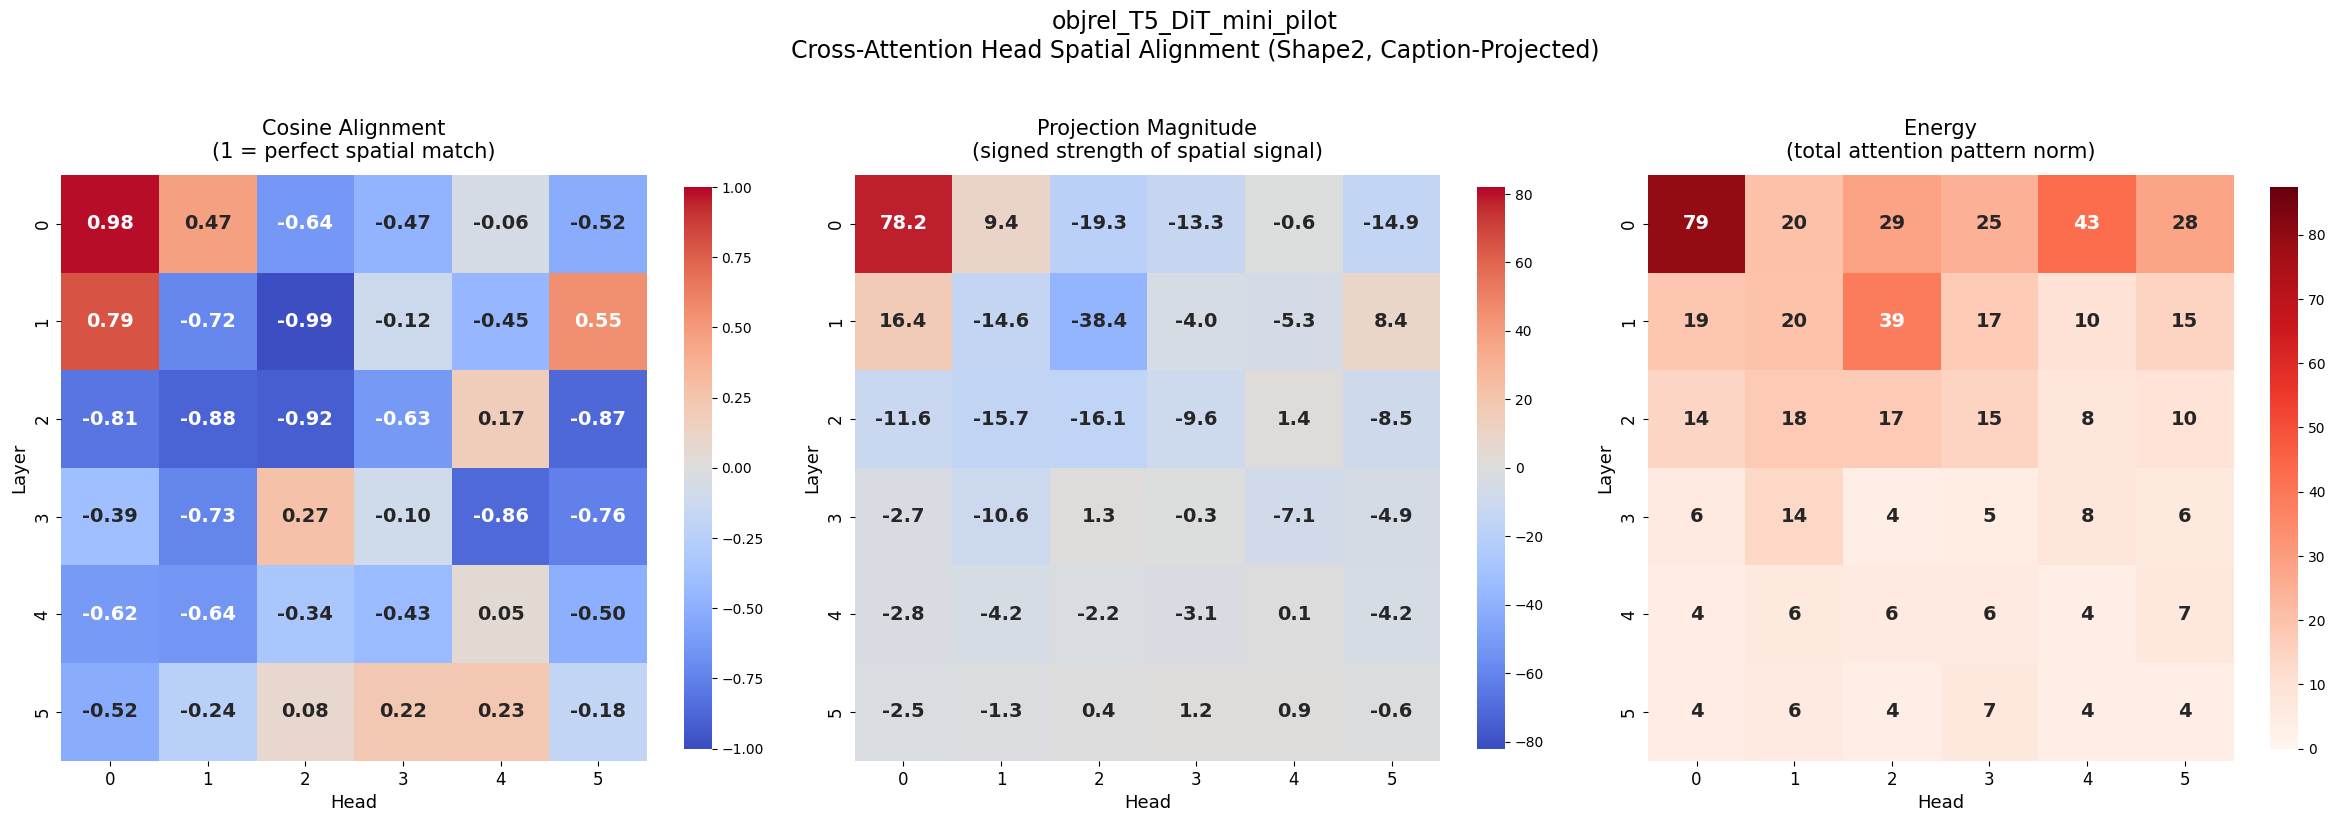

In [16]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape2_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

# Use data-driven color limits for projection so weak heads aren't washed out
proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

# Highlight top spatial heads
print("Top spatial heads (by |cosine| > 0.7):")
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        l, h = row.name
        print(f"  Layer {l}, Head {h}: cosine={row['cosine']:.2f}, proj={row['projection']:.1f}, energy={row['energy']:.0f}")

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape2, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape2_MLP_proj_rel_factor")
plt.show()

### Permutation Test for Head Alignment Significance

To confirm that the observed alignment scores are not due to chance structure in the data, we perform a permutation test. For each of N_PERM_NULL iterations, we shuffle the spatial_relationship labels across prompts, recompute variance partition effect vectors, and measure the maximum |cosine| alignment across all heads. This builds a null distribution against which we compare each head's observed score.


In [ ]:
# Permutation null distribution for alignment significance
import numpy as np

np.random.seed(42)
null_max_cosines = []

for perm_i in tqdm(range(N_PERM_NULL), desc="Permutation null"):
    # Shuffle relation labels across prompts
    shuffled_relations = np.random.permutation(
        prompt_scene_info_all_df["spatial_relationship"].values
    )
    shuffled_df = prompt_scene_info_all_df.copy()
    shuffled_df["spatial_relationship"] = shuffled_relations

    # Recompute variance partition with shuffled labels
    try:
        vp_shuf, intercept_shuf, ev_shuf, lm_shuf, r2_shuf = variance_partition_with_effects(
            wordvec_obj2_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": shuffled_df["spatial_relationship"],
             "shape1": shuffled_df["shape1"],
             "color2shape2": shuffled_df["color2shape2"]},
            metric="euclidean",
            n_perm=0,  # skip p-values for speed
            verbose=False,
        )
    except Exception:
        null_max_cosines.append(0.0)
        continue

    if "spatial_relationship" not in ev_shuf:
        null_max_cosines.append(0.0)
        continue

    # Compute alignment with shuffled effect vectors
    shuf_rel_vecs = ev_shuf["spatial_relationship"]
    shuf_target = torch.from_numpy(shuf_rel_vecs)[None, :].to(dtype=compute_dtype, device=device)
    max_cos_this_perm = 0.0
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(shuf_target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed_t = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed_t.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df_tmp = eval_ramp_alignment_all(inner_prod_mat, lm_shuf["spatial_relationship"])
        cos_vals = align_df_tmp["cosine"].abs()
        max_cos_this_perm = max(max_cos_this_perm, cos_vals.max())
    null_max_cosines.append(max_cos_this_perm)

null_max_cosines = np.array(null_max_cosines)
print(f"Null distribution: mean={null_max_cosines.mean():.3f}, "
      f"95th={np.percentile(null_max_cosines, 95):.3f}, "
      f"max={null_max_cosines.max():.3f}")

# Per-head p-values
observed_max_cos = head_align_synopsis["cosine"].abs()
for (layer_idx, head_idx), obs_cos in observed_max_cos.items():
    p_val = (null_max_cosines >= obs_cos).mean()
    if obs_cos > ALIGNMENT_COSINE_THRESHOLD:
        print(f"  Head L{layer_idx}H{head_idx}: |cos|={obs_cos:.3f}, p={p_val:.4f} {'***' if p_val < 0.01 else '**' if p_val < 0.05 else ''}")

### Section C.1 - Shape1/Object1 Alignment (Negative Control)

Negative control: object-identity heads show low spatial alignment. We repeat the alignment scan using object1 (shape1) features and verify that spatial-relation heads are specific to relations, not object identity.


In [ ]:
# Negative control: shape1 alignment scan (condensed)
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("Negative control: shape1 (object1) alignment")
var_part_df_S1, intercept_S1, effect_vecs_S1, levels_map_S1, R2_total_S1 = variance_partition_with_effects(wordvec_obj1_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
             },
            metric="euclidean",
            n_perm=N_PERM)

# Run alignment loop for shape1
from tqdm import tqdm
from itertools import product
align_df_list_S1 = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num)), desc="Shape1 alignment"):
    target_embedding_direction = effect_vecs_S1["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_S1["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list_S1.append(align_df)
align_df_allheads_S1 = pd.concat(align_df_list_S1)

# Quick summary: max |cosine| for shape1 vs shape2
synopsis_S1 = align_df_allheads_S1.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
print(f"Shape1 max |cosine|: {synopsis_S1['cosine'].abs().max():.3f}")
print(f"Shape2 max |cosine|: {head_align_synopsis['cosine'].abs().max():.3f}")
print("Shape1 alignment is substantially lower, confirming spatial heads are relation-specific.")

### Section C.2 - Selective Head Visualization

Generates focused plots for selected high-value heads/layers so you can quickly inspect spatial ramp structure without scanning all heads.

Text(0.5, 0.98, 'objrel_T5_DiT_mini_pilot\nL0H0 pos embed inner product with spatial relation factors in Caption Projection')

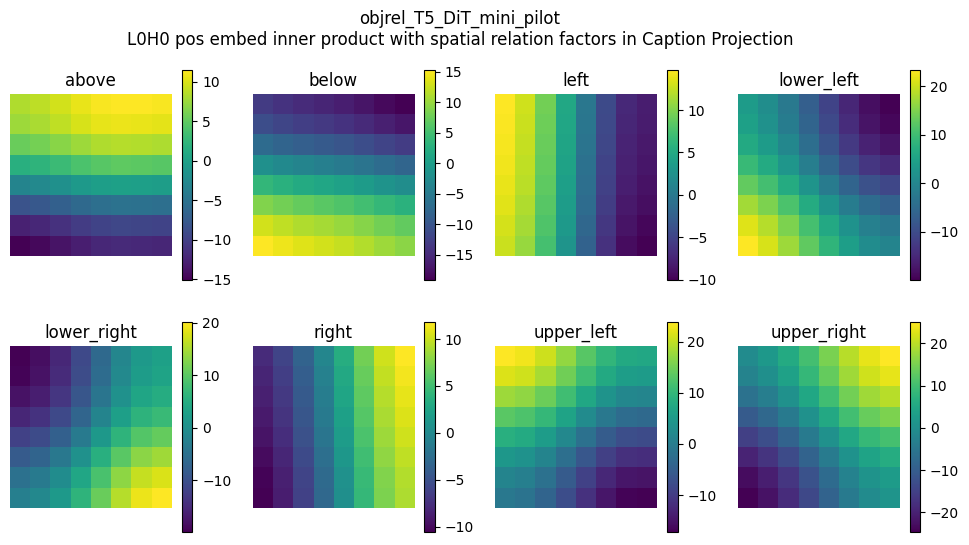

In [20]:
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
# Pick a layer/head to inspect — update after seeing the heatmaps above
layer_idx, head_idx = 0,0
target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()
for i_word in range(len(effect_vecs["spatial_relationship"])):
    plt.sca(axs[i_word])
    attn_score = inner_prod_mat[:, i_word:i_word+1]
    plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
    plt.title(f"{levels_map['spatial_relationship'][i_word]}")
    plt.axis("off")
    plt.colorbar()
plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with spatial relation factors in Caption Projection")

In [21]:
from utils.pixart_utils import PixArt_model_configs
def compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, feature_vecs, levels_names=None, 
                                   model_run_name="model", device=device, visualize=True):
    """
    Visualize the inner product between 2D positional embeddings and target effect vectors for specified head/layer.
    """
    transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
    hidden_size = transformer_config["hidden_size"]
    head_num = transformer_config["num_heads"]
    layer_num = transformer_config["depth"]
    base_size = 16 // 2
    head_dim = hidden_size // head_num

    target_embedding_direction = feature_vecs[:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
    if visualize:
        num_levels = len(feature_vecs)
        nrows, ncols = (2, 4) if num_levels == 8 else (1, num_levels)
        fig, axs = plt.subplots(nrows, ncols, figsize=(12, 6))
        axs = axs.flatten() if hasattr(axs, "flatten") else [axs]

        for i_word in range(num_levels):
            plt.sca(axs[i_word])
            attn_score = inner_prod_mat[:, i_word:i_word+1]
            plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
            if levels_names is not None:
                plt.title(f"{levels_names[i_word]}")
            else:
                plt.title(f"{i_word}")
            plt.axis("off")
            plt.colorbar()
        plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with {len(feature_vecs)} factors in Caption Projection")
        plt.tight_layout()
        plt.show()
    else:
        fig = None
    return inner_prod_mat, fig

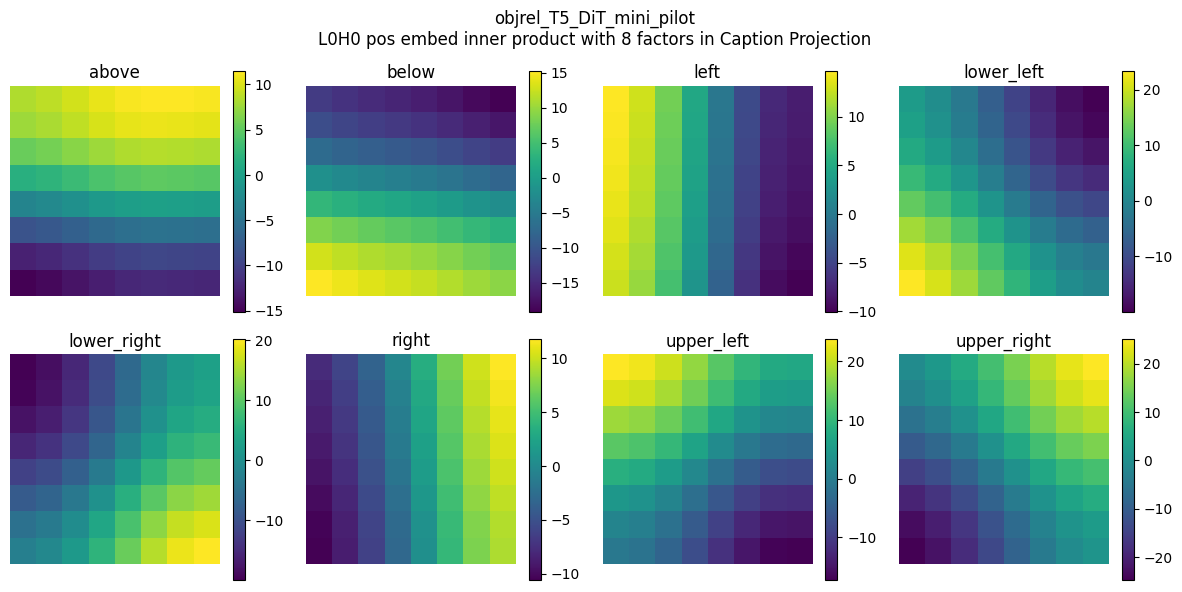

In [22]:
# Example: inspect the strongest spatial head
inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, 0, 0, 
                                 effect_vecs["spatial_relationship"], 
                                 levels_names=levels_map["spatial_relationship"], 
                                 model_run_name=model_run_name, 
                                 device=device, visualize=True);

Visualizing 11 top spatial heads: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 1), (3, 4), (3, 5)]



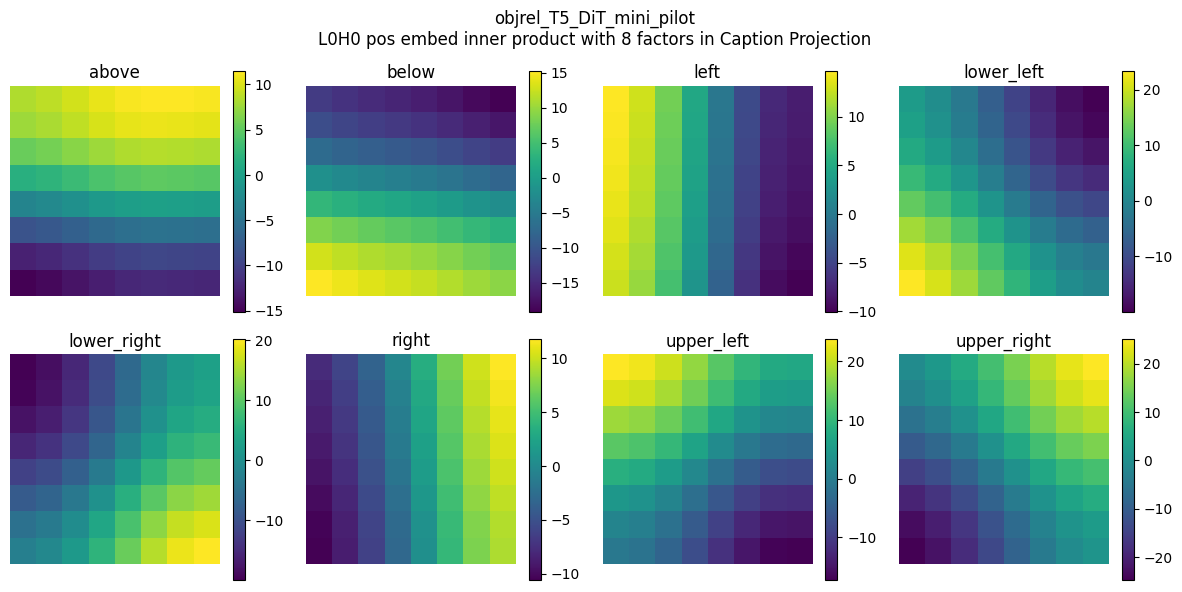

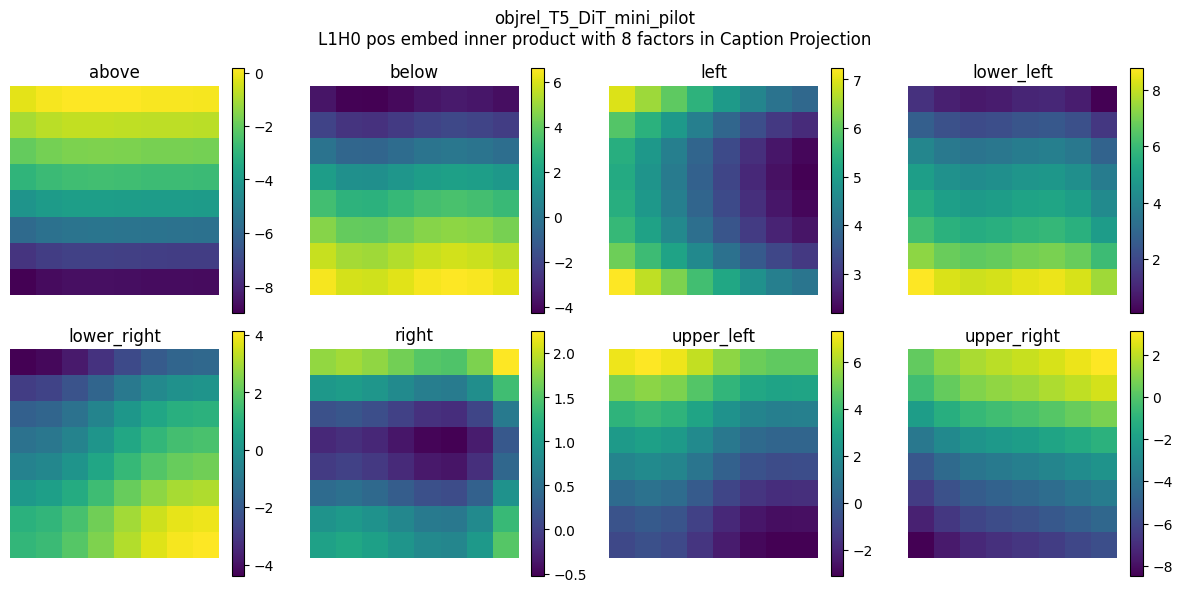

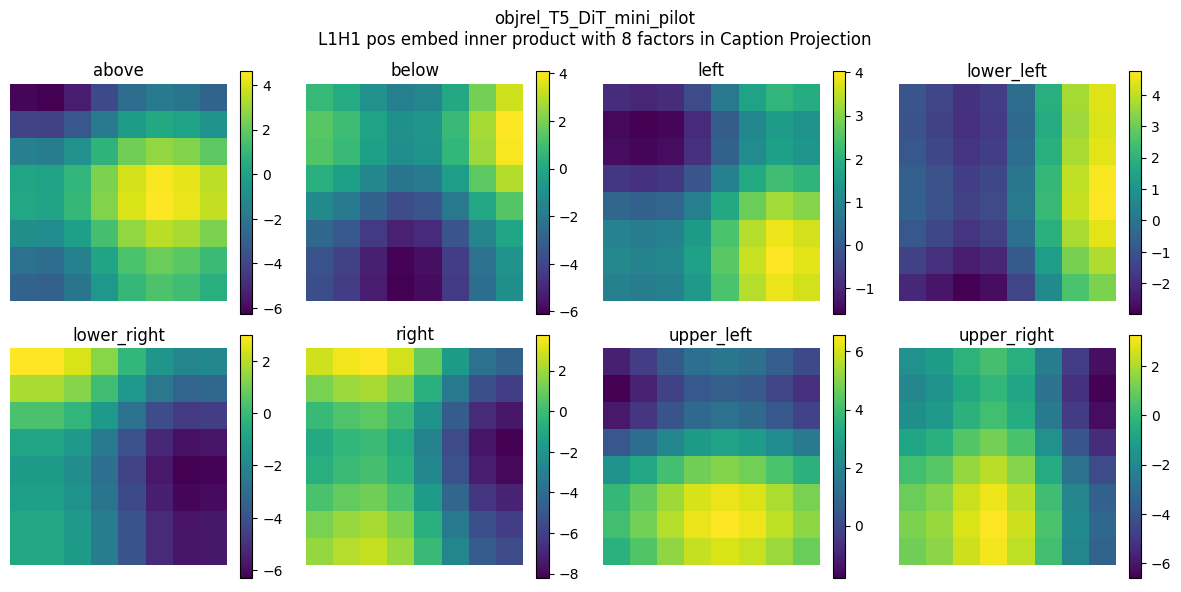

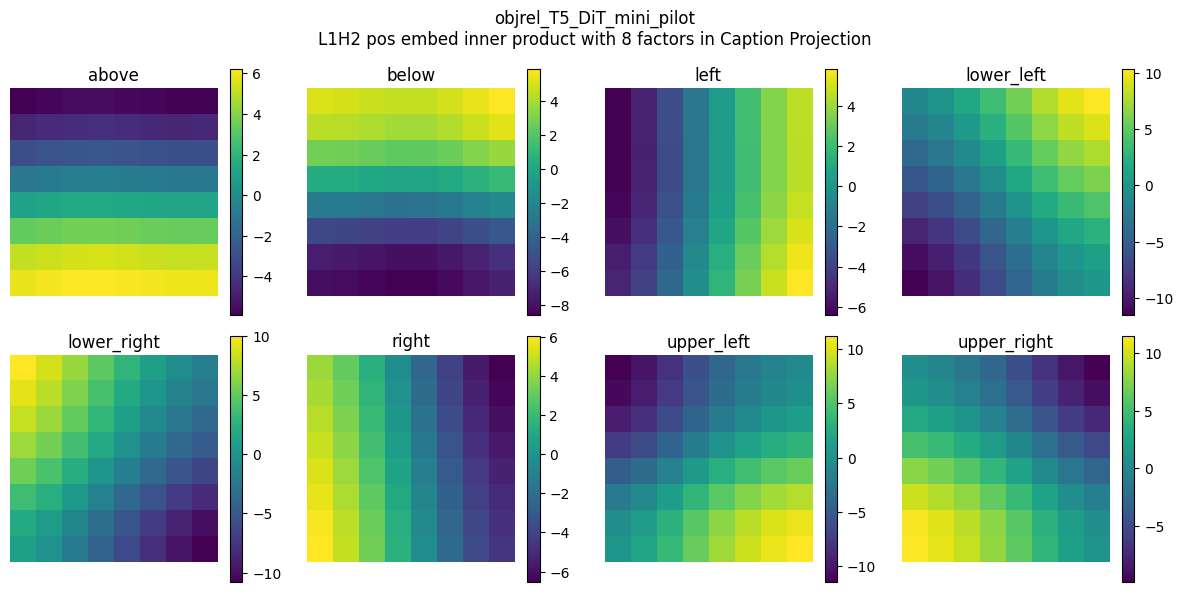

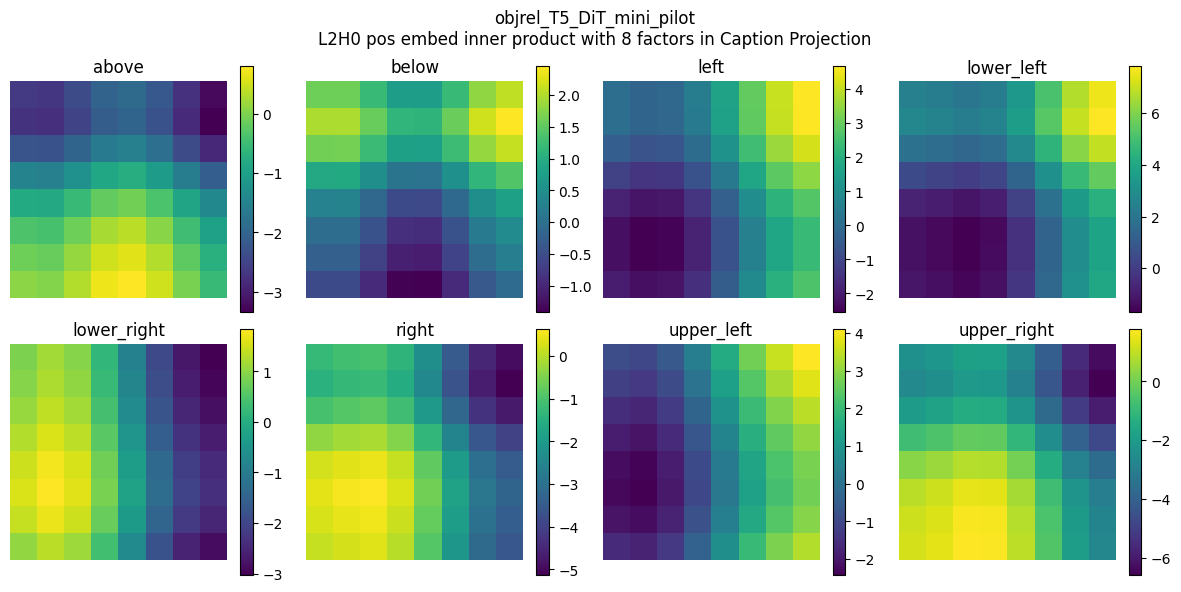

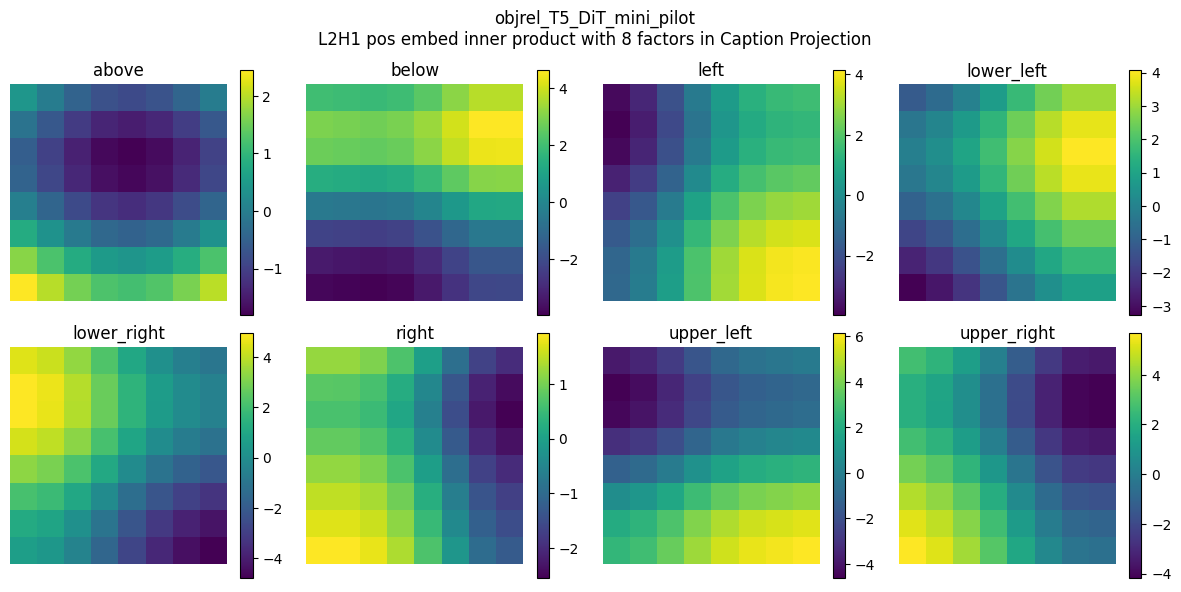

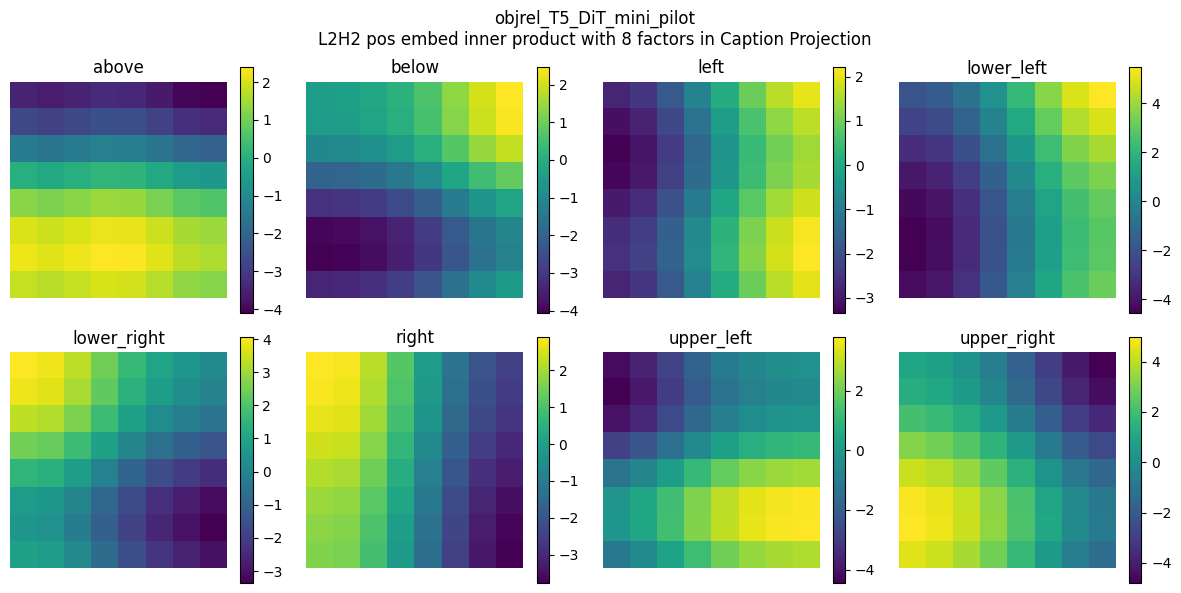

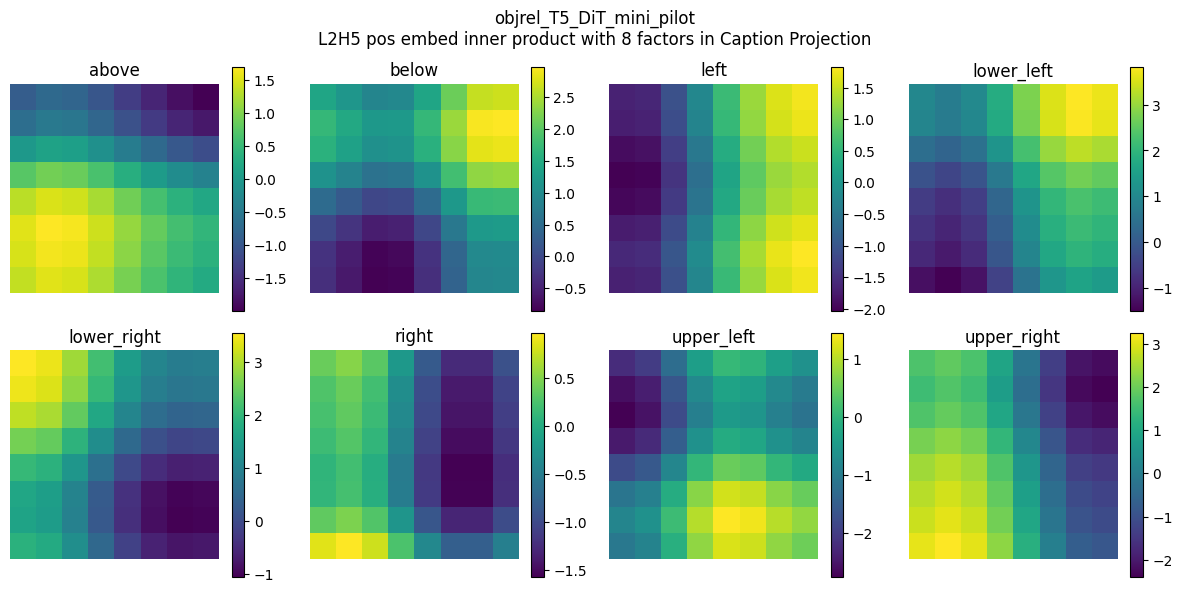

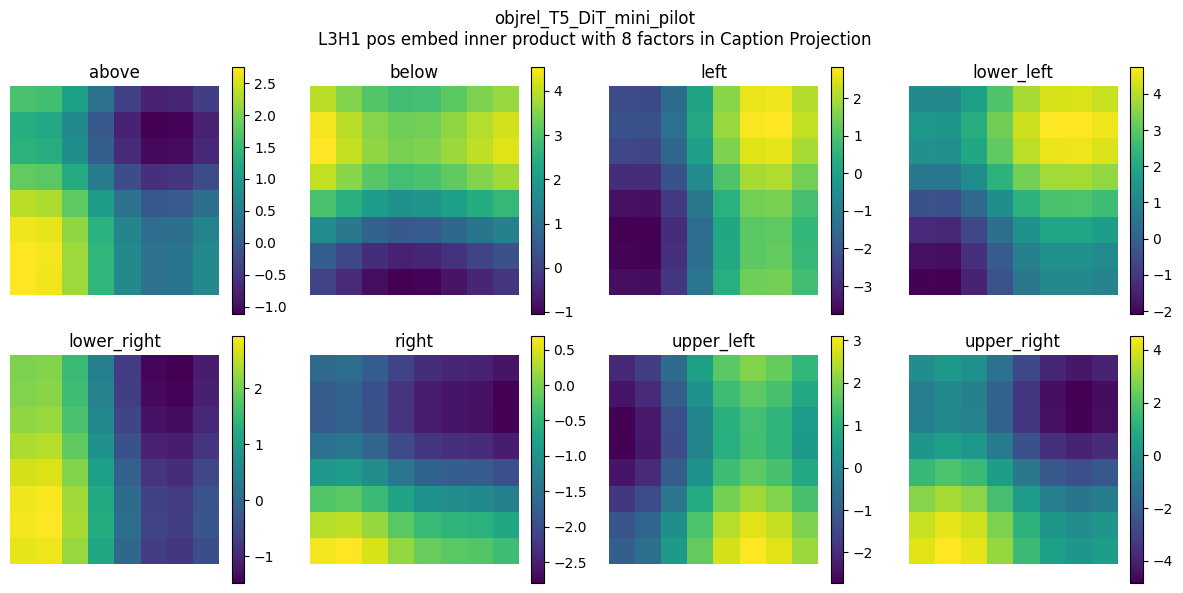

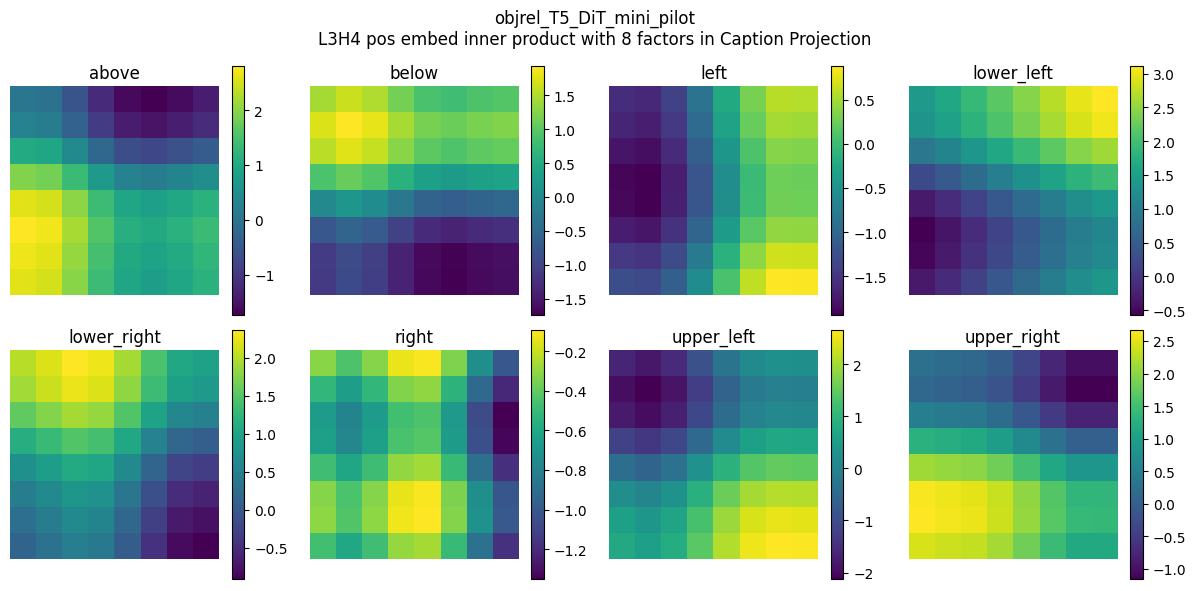

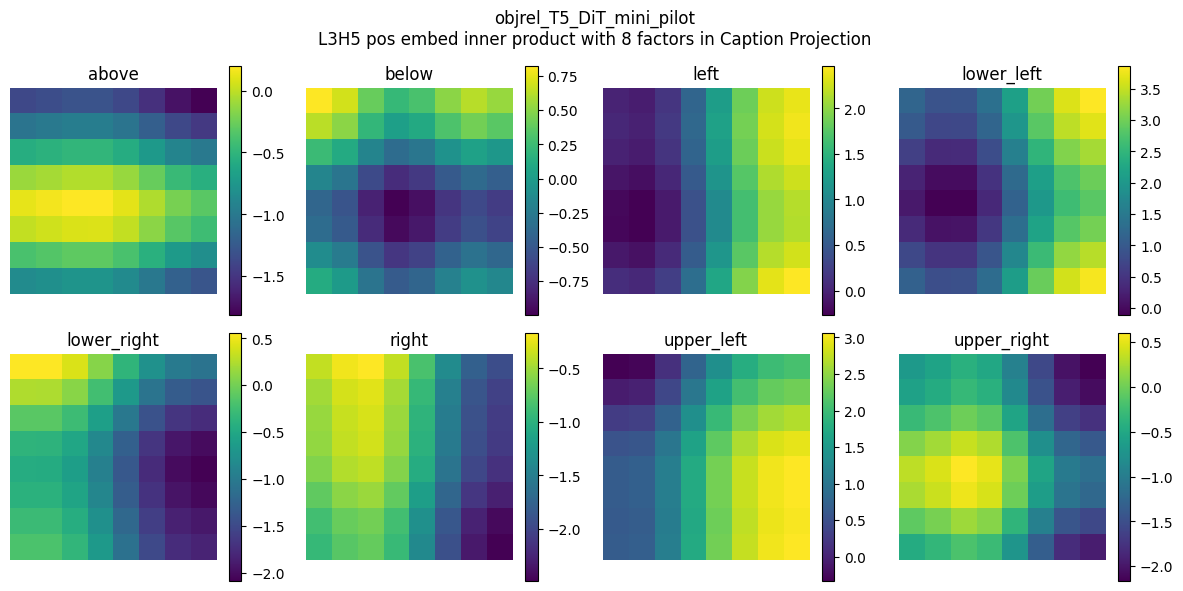

In [23]:
# Visualize the top spatial heads found from the heatmap above
# Pick heads with |cosine| > 0.7 automatically
top_heads = []
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append(row.name)  # (layer_idx, head_idx)

if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]  # fallback
    
print(f"Visualizing {len(top_heads)} top spatial heads: {top_heads}\n")
for layer_idx, head_idx in top_heads:
    inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, 
                                     effect_vecs["spatial_relationship"], 
                                     levels_names=levels_map["spatial_relationship"], 
                                     model_run_name=model_run_name, 
                                     device=device, visualize=True);

### Trace spatial heads through training

**Goal:** See how cross-attention head spatial alignment evolves across checkpoints.

**Key insight:** T5 embeddings are frozen → same raw embeddings for all checkpoints.  
But the **caption projection (MLP)** and **cross-attention weights** are trained → we must:
1. Load each checkpoint
2. Project cached T5 embeddings through that checkpoint's caption_projection
3. Run variance partition on projected embeddings (effect_vecs differ per checkpoint)
4. Run head alignment using that checkpoint's attn2 weights + effect_vecs

In [24]:
# Define checkpoints to trace (epoch, step) and load order
ckpt_files = [
    "epoch_100_step_4000.pth",
    "epoch_250_step_10000.pth",
    "epoch_500_step_20000.pth",
    "epoch_1000_step_40000.pth",
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
# Fine-grained checkpoints for 500–1000 (relation head emergence)
ckpt_files_emergence = [
    "epoch_500_step_20000.pth",
    "epoch_600_step_24000.pth",
    "epoch_700_step_28000.pth",
    "epoch_750_step_30000.pth",
    "epoch_800_step_32000.pth",
    "epoch_900_step_36000.pth",
    "epoch_1000_step_40000.pth",
]
# Extended ablation: emergence + later checkpoints (2000, 4000) where relation head should be stronger
ckpt_files_ablation = ckpt_files_emergence + [
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
ckptdir = join(savedir, "checkpoints")
print(f"Full trace: {len(ckpt_files)} checkpoints | Emergence (500–1000): {len(ckpt_files_emergence)} | Ablation sweep: {len(ckpt_files_ablation)}")

Full trace: 6 checkpoints | Emergence (500–1000): 7 | Ablation sweep: 9


In [25]:
# For each checkpoint: load, project embeddings, variance partition, head alignment
# Results stored in evolution_records (list of DataFrames, one per checkpoint)

n_perm_evolution = 50  # Reduce for faster run (original uses 100)
evolution_records = []
var_part_evolution = []
q_norms_evolution = []
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

for ckpt_name in tqdm(ckpt_files, desc="Checkpoints"):
    # 1. Load checkpoint into transformer (reuse existing pipeline structure)
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    
    # 2. Project cached T5 embeddings through this checkpoint's caption_projection
    wordvec_obj1_col, wordvec_obj2_col = [], []
    for row in prompt_scene_info_all_df.itertuples():
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([token_id]) for token_id in tokenized['input_ids'][0]]
        shape1_mask_idx = find_shape_index(tokens, row.shape1)
        shape2_mask_idx = find_shape_index(tokens, row.shape2)
        wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
        wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
    wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
        wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    # 3. Variance partition on projected embeddings (Shape2)
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    var_part_df_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, R2_total_ckpt = variance_partition_with_effects(
        wordvec_obj2_mat_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    
    # 4. Head alignment for this checkpoint
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    
    align_df = pd.concat(align_df_list)
    head_synopsis = align_df.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["checkpoint"] = ckpt_name
    epoch = int(ckpt_name.split("_")[1])
    head_synopsis["epoch"] = epoch
    evolution_records.append(head_synopsis.reset_index())
    
    # Variance partition: R² per factor (MLP-projected embedding)
    var_part_ckpt = var_part_df_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_ckpt["checkpoint"] = ckpt_name
    if ckpt_name == ckpt_files[0]:
        var_part_evolution = [var_part_ckpt]
    else:
        var_part_evolution.append(var_part_ckpt)
    
    # Q weight norms per head (cross-attention projection)
    q_norms_ckpt = []
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_ckpt.append({
                "epoch": epoch, "checkpoint": ckpt_name,
                "layer_idx": layer_idx, "head_idx": head_idx,
                "q_norm": q_heads[head_idx].norm().item(),
            })
    if ckpt_name == ckpt_files[0]:
        q_norms_evolution = q_norms_ckpt
    else:
        q_norms_evolution.extend(q_norms_ckpt)

Checkpoints: 100%|██████████| 6/6 [00:05<00:00,  1.18it/s]


In [26]:
# Combine all checkpoint results into one evolution DataFrame
evolution_df = pd.concat(evolution_records, ignore_index=True)
evolution_df = evolution_df.sort_values(["epoch", "layer_idx", "head_idx"]).reset_index(drop=True)

var_part_evolution = globals().get('var_part_evolution', [])
q_norms_evolution = globals().get('q_norms_evolution', [])
var_part_df_evolution = pd.concat(var_part_evolution, ignore_index=True) if var_part_evolution else pd.DataFrame()
q_norms_df = pd.DataFrame(q_norms_evolution) if q_norms_evolution else pd.DataFrame()

print(evolution_df.head(6))
print(f"\nEvolution: {len(evolution_df)} rows | Var partition: {len(var_part_df_evolution)} rows | Q norms: {len(q_norms_df)} rows")
if var_part_df_evolution.empty or q_norms_df.empty:
    print("\n⚠ Run the evolution loop (cell above) first to populate var_part_evolution and q_norms_evolution.")

   layer_idx  head_idx    cosine  projection    energy  template_norm  \
0          0         0  0.062626    0.008058  0.043573       5.237229   
1          0         1 -0.134555   -0.001923  0.058366       5.237229   
2          0         2 -0.111684   -0.003656  0.024893       5.237229   
3          0         3 -0.076353   -0.002659  0.030721       5.237229   
4          0         4  0.132962    0.004712  0.044418       5.237229   
5          0         5  0.177412    0.009673  0.062580       5.237229   

   dir_idx               checkpoint  epoch  
0      3.5  epoch_100_step_4000.pth    100  
1      3.5  epoch_100_step_4000.pth    100  
2      3.5  epoch_100_step_4000.pth    100  
3      3.5  epoch_100_step_4000.pth    100  
4      3.5  epoch_100_step_4000.pth    100  
5      3.5  epoch_100_step_4000.pth    100  

Evolution: 216 rows | Var partition: 18 rows | Q norms: 216 rows


#### Evolution of key spatial heads over training

Plot cosine, projection, and energy for the top heads (e.g., L0H0, L1H2) across epochs.

Plotting evolution for: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 1), (3, 4), (3, 5)]


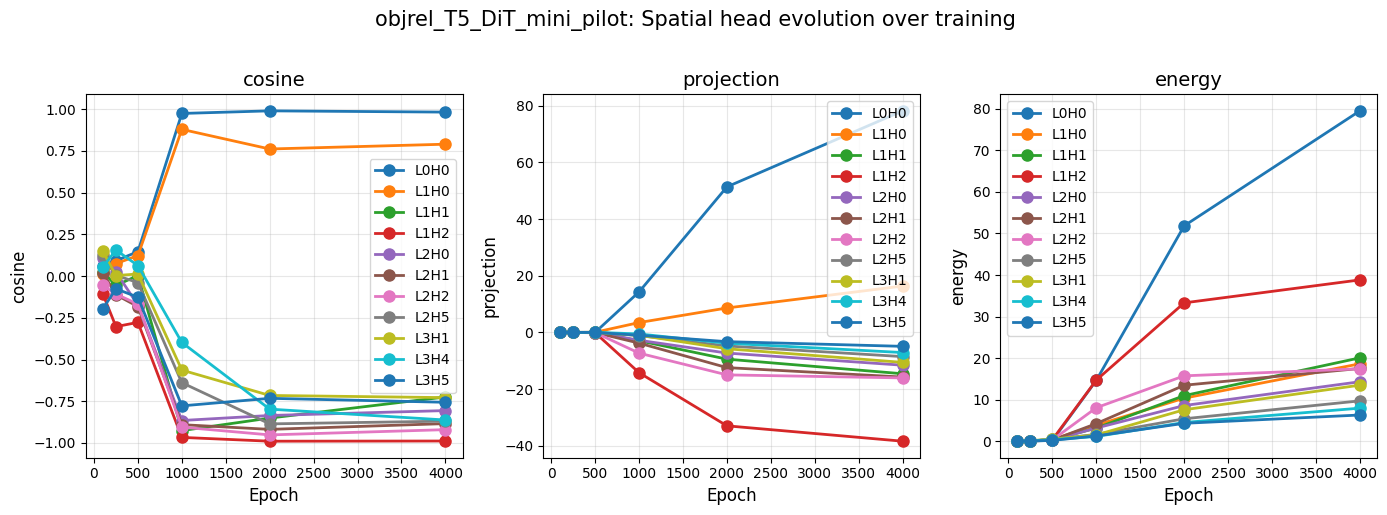

In [27]:
# Plot evolution of top spatial heads (auto-pick from final checkpoint |cosine| > 0.7)
final_ckpt = evolution_df[evolution_df["epoch"] == evolution_df["epoch"].max()]
top_heads = []
for _, row in final_ckpt.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]
print(f"Plotting evolution for: {top_heads}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["cosine", "projection", "energy"]):
    for layer_idx, head_idx in top_heads:
        subset = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
        ax.plot(subset["epoch"], subset[metric], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=8)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Spatial head evolution over training", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

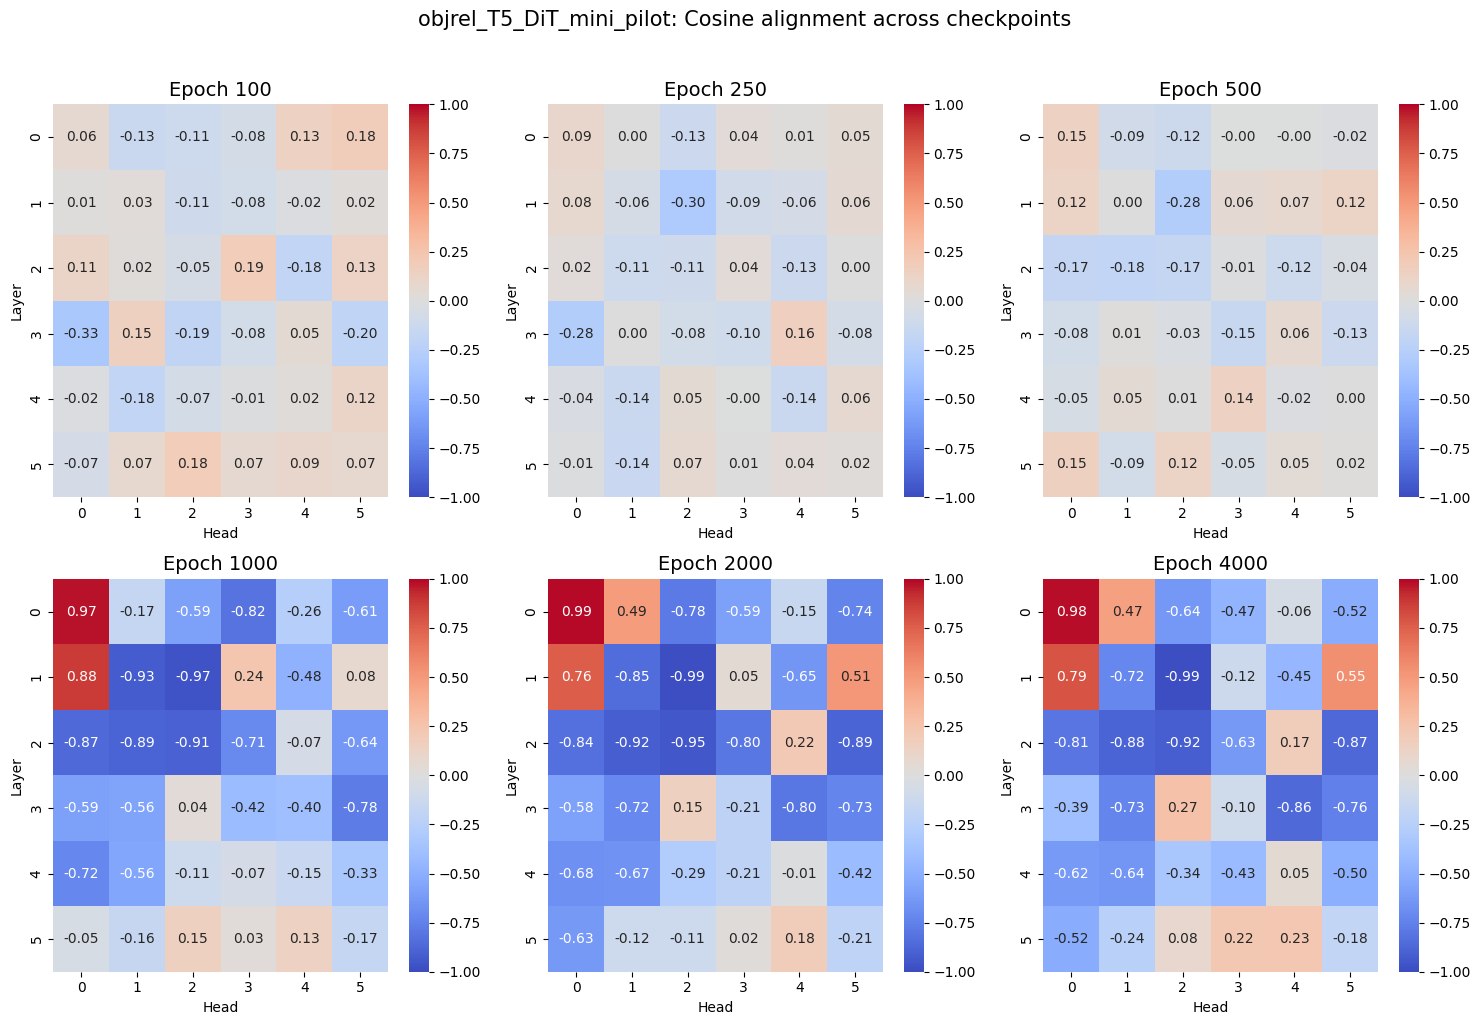

In [28]:
# Cosine alignment heatmaps across all checkpoints
epochs = sorted(evolution_df["epoch"].unique())
n_ckpts = len(epochs)
ncols = 3
nrows = (n_ckpts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for idx, epoch in enumerate(epochs):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df[evolution_df["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")

for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)

plt.suptitle(f"{model_run_name}: Cosine alignment across checkpoints", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Relation head emergence (epochs 500–1000)

Fine-grained view using checkpoints 500, 600, 700, 750, 800, 900, 1000 — where the spatial relation head becomes identifiable.

In [31]:
# Run evolution for emergence checkpoints only (500–1000)
# Uses same config as main loop (layer_num, head_num, etc. from cell 32)
transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

evo_em_records, var_part_em, q_norms_em = [], [], []
for ckpt_name in tqdm(ckpt_files_emergence, desc="Emergence checkpoints"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    
    wordvec_obj2_col = []
    for row in prompt_scene_info_all_df.itertuples():
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
        shape2_idx = find_shape_index(tokens, row.shape2)
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    var_part_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, _ = variance_partition_with_effects(
        wordvec_obj2_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    var_part_ckpt = var_part_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_em.append(var_part_ckpt)
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evo_em_records.append(head_synopsis.reset_index())
    
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_em.append({"epoch": epoch, "layer_idx": layer_idx, "head_idx": head_idx, "q_norm": q_heads[head_idx].norm().item()})

evolution_df_em = pd.concat(evo_em_records, ignore_index=True)
var_part_df_em = pd.concat(var_part_em, ignore_index=True)
q_norms_df_em = pd.DataFrame(q_norms_em)
print(f"Emergence data: {len(evolution_df_em)} alignment rows, {len(var_part_df_em)} var partition rows")

Emergence checkpoints: 100%|██████████| 7/7 [00:05<00:00,  1.19it/s]

Emergence data: 252 alignment rows, 21 var partition rows


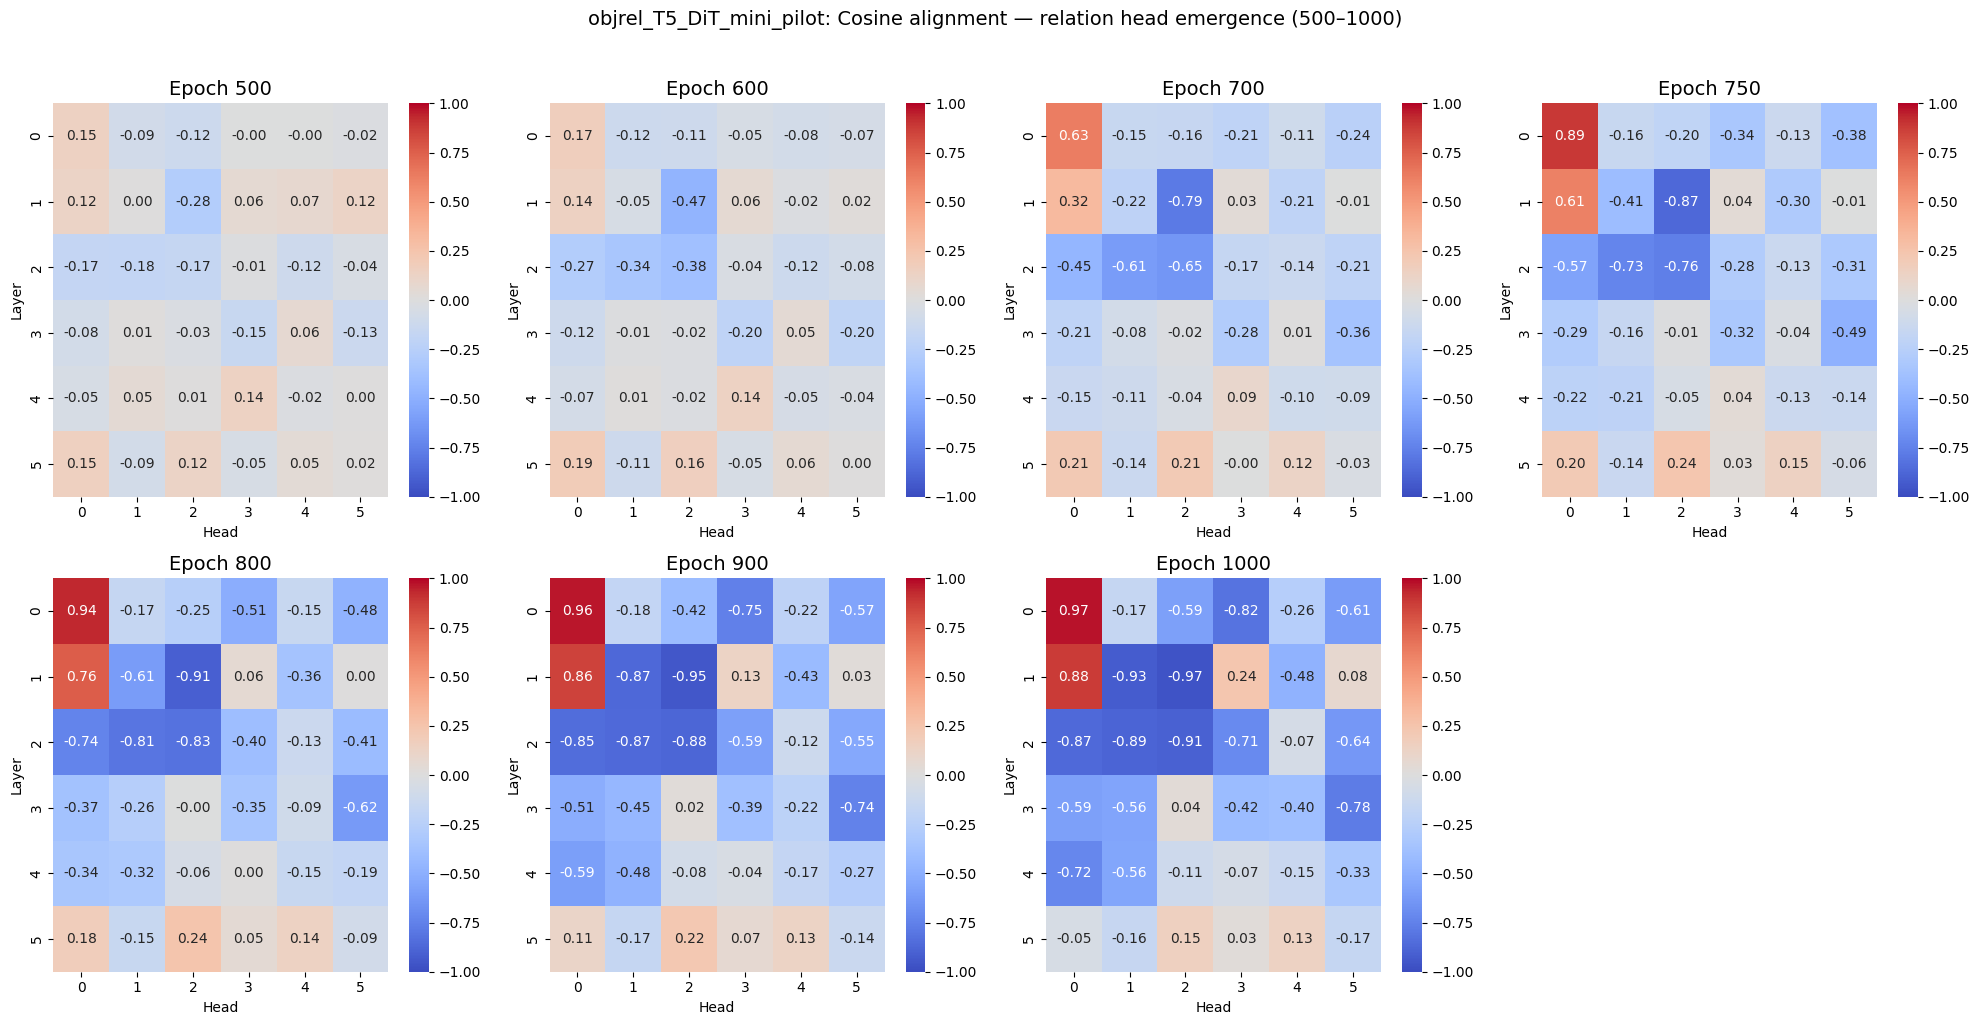

In [32]:
# Cosine alignment heatmaps: 500–1000 (relation head emergence)
epochs_em = sorted(evolution_df_em["epoch"].unique())
n_ckpts = len(epochs_em)
ncols = 4
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_em):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment — relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

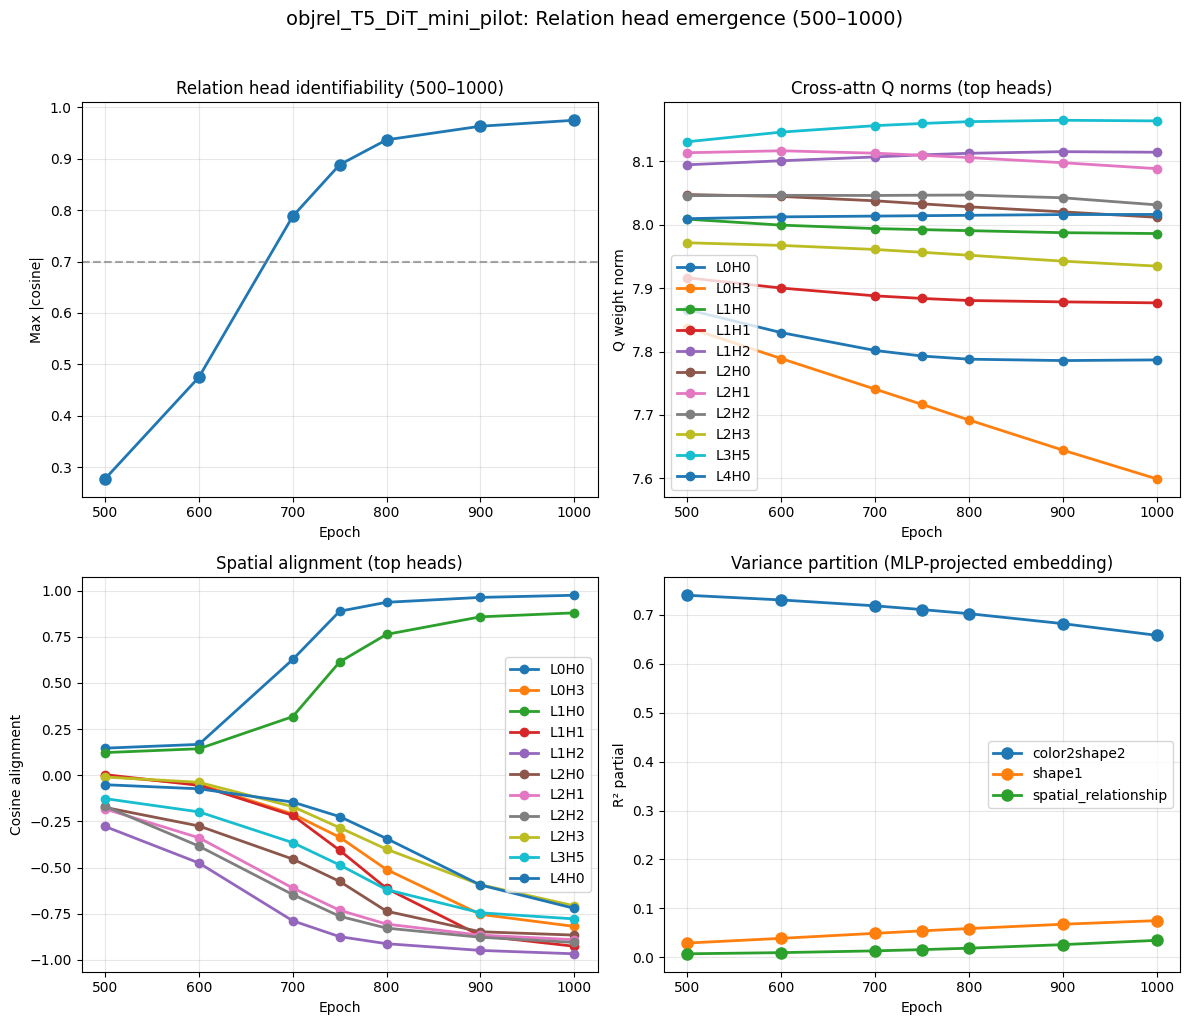

In [33]:
# Emergence: identifiability, projection norms, variance partition
top_em = []
for _, row in evolution_df_em[evolution_df_em["epoch"] == evolution_df_em["epoch"].max()].iterrows():
    if abs(row["cosine"]) > 0.7:
        top_em.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_em:
    top_em = [(0, 0), (1, 2), (2, 3)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Max |cosine| and gap
id_em = []
for epoch in sorted(evolution_df_em["epoch"].unique()):
    sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    abs_cos = sub["cosine"].abs()
    max_idx = abs_cos.idxmax()
    row = sub.loc[max_idx]
    top_layer, top_head = int(row["layer_idx"]), int(row["head_idx"])
    mean_other = sub[(sub["layer_idx"] != top_layer) | (sub["head_idx"] != top_head)]["cosine"].abs().mean()
    id_em.append({"epoch": epoch, "max_abs_cosine": abs(row["cosine"]), "gap": abs(row["cosine"]) - mean_other})
id_em = pd.DataFrame(id_em)
axes[0, 0].plot(id_em["epoch"], id_em["max_abs_cosine"], "o-", linewidth=2, markersize=8)
axes[0, 0].axhline(0.7, color="gray", linestyle="--", alpha=0.7)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Max |cosine|")
axes[0, 0].set_title("Relation head identifiability (500–1000)")
axes[0, 0].grid(True, alpha=0.3)

# (b) Q norms for top heads
for layer_idx, head_idx in top_em:
    sub = q_norms_df_em[(q_norms_df_em["layer_idx"] == layer_idx) & (q_norms_df_em["head_idx"] == head_idx)]
    axes[0, 1].plot(sub["epoch"], sub["q_norm"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Q weight norm")
axes[0, 1].set_title("Cross-attn Q norms (top heads)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Cosine for top heads
for layer_idx, head_idx in top_em:
    sub = evolution_df_em[(evolution_df_em["layer_idx"] == layer_idx) & (evolution_df_em["head_idx"] == head_idx)]
    axes[1, 0].plot(sub["epoch"], sub["cosine"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Cosine alignment")
axes[1, 0].set_title("Spatial alignment (top heads)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# (d) Variance partition (R² partial)
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
for col in vp_em.columns:
    axes[1, 1].plot(vp_em.index, vp_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("R² partial")
axes[1, 1].set_title("Variance partition (MLP-projected embedding)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"{model_run_name}: Relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

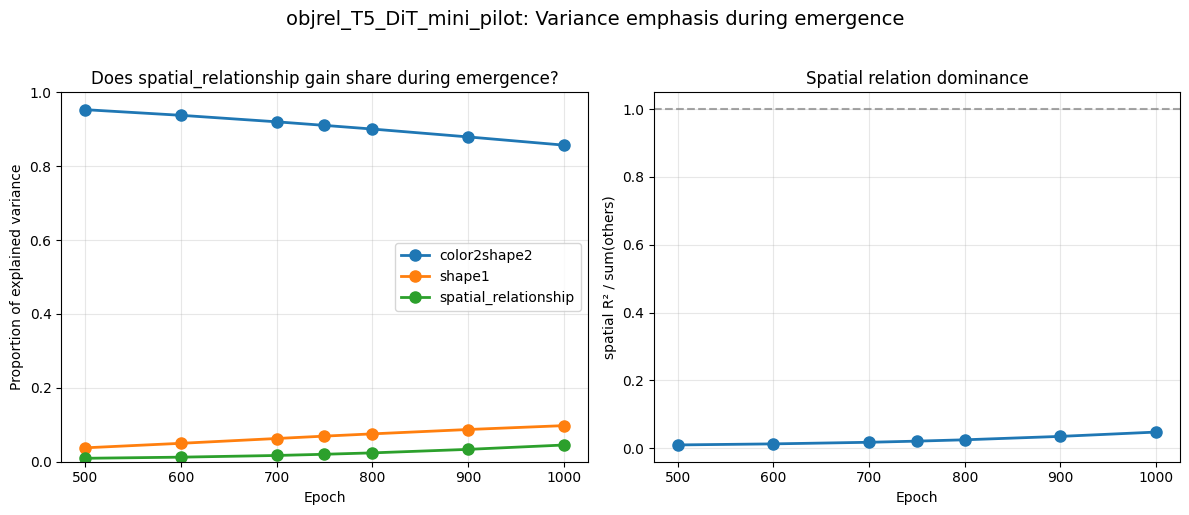

In [34]:
# Emergence: variance proportion and spatial dominance
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
vp_prop_em = vp_em.div(vp_em.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col in vp_prop_em.columns:
    axes[0].plot(vp_prop_em.index, vp_prop_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Proportion of explained variance")
axes[0].set_title("Does spatial_relationship gain share during emergence?")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

if "spatial_relationship" in vp_em.columns:
    others = [c for c in vp_em.columns if c != "spatial_relationship"]
    ratio_em = vp_em["spatial_relationship"] / (vp_em[others].sum(axis=1) + 1e-10)
    axes[1].plot(vp_em.index, ratio_em, "o-", color="C0", linewidth=2, markersize=8)
    axes[1].axhline(1, color="gray", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("spatial R² / sum(others)")
    axes[1].set_title("Spatial relation dominance")
    axes[1].grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Variance emphasis during emergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

Key findings from head discovery:
- **Head screening** identified candidate relation-sensitive heads via spatial alignment of attention patterns to 2D positional embedding ramps
- **Permutation null** confirms the top heads' alignment is significant (p < 0.05 after label shuffling)
- **Shape1 control** shows these heads are specific to spatial relations, not object identity
- **Training evolution** reveals relation heads emerge between epochs 500-1000, with a sharp transition in alignment metrics
- **Emergence analysis** provides fine-grained view of the critical training window

Next: proceed to `02_ablation_and_causality.ipynb` for causal verification of these candidate heads.
